# Network Growth Simulation

Forward growth simulation of the LTS ≤ 2 cycling network. Starting from the
existing low-stress subnetwork, high-stress (LTS 3–4) candidate edges are
upgraded one at a time under three selection strategies, and connectivity is
tracked as a function of cumulative upgraded length.

Operates on the **undirected projection** of the directed LTS network: each
undirected edge takes the **worse** LTS of its two directions, so both directions
must meet the LTS 2 standard for an edge to count as low-stress.

**Two metrics** (computed at intervals during growth):

| Metric | Definition |
|--------|------------|
| **LCC share** | Length of the largest connected component ÷ total length of the current LTS ≤ 2 subnetwork |
| **Demand-weighted connectivity** | Share of Census 2011 commuting flow (straight-line ≤ 8 km) whose origin and destination fall in the same LTS ≤ 2 component |

**Three strategies** (topology-to-demand axis):

| Strategy | Selection logic | Information input | Candidate set |
|----------|-----------------|-------------------|---------------|
| **Random** | Uniform random over all candidates; 10 runs averaged | None (null baseline) | all remaining |
| **Connectivity** | Adjacent edges merging distinct components, favouring the largest component; ties by shortest length | Network topology | frontier (adjacent) |
| **BC** | Highest pre-computed edge betweenness centrality | Topological demand proxy | all remaining |

**Candidate-set asymmetry (intentional, matches the dissertation Table).**
Random and BC select from *all remaining* candidates via a fixed global ordering
(`run_fixed_order`); Connectivity selects only from the *frontier* of edges
adjacent to the current subnetwork (`run_growth`). Because Random and BC can add
edges that do not touch the existing network, at a given cumulative length they
spend some upgrade budget on isolated edges, which is the null-baseline behaviour
the comparison is designed to expose.

Inputs: `network_lts_with_bc.gpkg` (edge BC precomputed upstream), Census 2011
MSOA OD data. Growth operates on the undirected projection.

In [22]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

DATA_DIR    = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR  = Path('../Data/Cleaned')
FIG_DIR     = Path('../Figures')
FIG_DIR.mkdir(exist_ok=True)

CRS_BNG = 'EPSG:27700'
SL_DIST_THRESHOLD = 8_000  # 8 km straight-line OD filter

STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]

N_RANDOM_RUNS = 10
METRIC_INTERVAL = 100  # compute metrics every N upgraded edges

## 1. Union-Find data structure

In [23]:
class UnionFind:
    """Weighted Union-Find with path compression."""
    def __init__(self):
        self.parent = {}
        self.rank = {}
        self.comp_size = {}
        self.comp_length = defaultdict(float)

    def add(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0
            self.comp_size[x] = 1

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y, edge_length=0.0):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            self.comp_length[rx] += edge_length
            return False
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        self.comp_size[rx] += self.comp_size[ry]
        self.comp_length[rx] += self.comp_length[ry] + edge_length
        del self.comp_size[ry]
        del self.comp_length[ry]
        return True

    def connected(self, x, y):
        if x not in self.parent or y not in self.parent:
            return False
        return self.find(x) == self.find(y)

    def largest_component_length(self):
        return max(self.comp_length.values()) if self.comp_length else 0.0

    def total_length(self):
        return sum(self.comp_length.values())

    def n_components(self):
        return len(self.comp_size)

## 2. Load network with BC

In [24]:
edges = gpd.read_file(CLEANED_DIR / "network_lts_with_bc.gpkg")
edges = edges.to_crs(CRS_BNG)
edges['length_m'] = edges['geometry_length_m'].astype(float)
edges['length_km'] = edges['length_m'] / 1000

print(f"Directed edges: {len(edges):,}")
print(f"LTS distribution:")
print(edges['lts_final'].value_counts().sort_index())

Directed edges: 480,228
LTS distribution:
lts_final
1.0    227858
2.0    150941
3.0     47077
4.0     54352
Name: count, dtype: int64


## 3. Undirected projection

One row per undirected edge. The worst-direction LTS (`lts_final: max`) determines
upgrade need; edge BC is aggregated as the max of the two directions (`bc: max`).

In [25]:
edges['u'] = edges[['from_node', 'to_node']].min(axis=1)
edges['v'] = edges[['from_node', 'to_node']].max(axis=1)

undir = (
    edges.groupby(['u', 'v'], as_index=False)
    .agg({'length_m': 'mean', 'lts_final': 'max', 'bc': 'max'})
)
undir['length_km'] = undir['length_m'] / 1000

lts2_mask = undir['lts_final'] <= 2
candidates = undir[~lts2_mask].copy().reset_index(drop=True)

print(f"Undirected edges: {len(undir):,}")
print(f"LTS ≤ 2 (initial): {lts2_mask.sum():,}")
print(f"LTS 3-4 (candidates): {len(candidates):,}")

Undirected edges: 255,286
LTS ≤ 2 (initial): 187,370
LTS 3-4 (candidates): 67,916


## 4. Node coordinates

In [26]:
node_coords = {}
for _, row in edges.iterrows():
    coords = list(row['geometry'].coords)
    u, v = row['from_node'], row['to_node']
    if u not in node_coords:
        node_coords[u] = np.array(coords[0][:2])
    if v not in node_coords:
        node_coords[v] = np.array(coords[-1][:2])
print(f"Node coordinates: {len(node_coords):,}")

Node coordinates: 253,548


## 5. Candidate adjacency index

Pre-build a mapping from each node to the candidate edges it touches.
This enables O(degree) frontier updates instead of O(|all nodes|) scans.

In [27]:
# node -> set of candidate indices that touch it
node_to_cand = defaultdict(set)
for idx, row in candidates.iterrows():
    node_to_cand[row['u']].add(idx)
    node_to_cand[row['v']].add(idx)

# Pre-extract candidate columns as numpy arrays for fast access
# (avoids pandas .loc overhead in hot loops)
cand_u = candidates['u'].values
cand_v = candidates['v'].values
cand_len = candidates['length_m'].values.astype(float)
cand_bc = candidates['bc'].values.astype(float)
cand_len_km = candidates['length_km'].values.astype(float)

print(f"Nodes touching candidates: {len(node_to_cand):,}")
print(f"Candidate arrays: {len(cand_u):,} edges")

Nodes touching candidates: 64,568
Candidate arrays: 67,916 edges


## 6. Census commuting OD data (≤ 8 km)

In [28]:
# Study area
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy().to_crs(CRS_BNG)

# MSOA boundaries
msoa = gpd.read_file(
    DATA_DIR / "Middle_Layer_Super_Output_Areas_Dec_2001_Boundaries_EW_BGC_2022_1570857564621828750.geojson"
)
msoa = msoa.to_crs(CRS_BNG)
msoa["centroid"] = msoa.geometry.centroid
msoa_centroids = msoa.set_geometry("centroid")
msoa_wm = gpd.sjoin(msoa_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
msoa_wm = msoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])
msoa_code_col = "MSOA21CD" if "MSOA21CD" in msoa_wm.columns else "MSOA01CD"
print(f"WM MSOAs: {len(msoa_wm)}")

WM MSOAs: 356


In [29]:
# Census OD
census_2011 = pd.read_csv(DATA_DIR / "census_2011/ODWP03EW_MSOA.csv")
census_2011["MSOA of workplace code"] = census_2011["MSOA of workplace code"].astype(str).str.strip()
census_2011["Middle layer Super Output Areas code"] = census_2011["Middle layer Super Output Areas code"].astype(str).str.strip()
census_2011 = census_2011[~census_2011["MSOA of workplace code"].isin({"-8", "999999999"})].copy()
census_2011["Place of work indicator (4 categories) code"] = pd.to_numeric(
    census_2011["Place of work indicator (4 categories) code"], errors="coerce"
)
census_2011 = census_2011[census_2011["Place of work indicator (4 categories) code"] == 3].copy()
census_2011["Count"] = pd.to_numeric(census_2011["Count"], errors="coerce").fillna(0).astype(int)

od = census_2011.groupby(
    ["Middle layer Super Output Areas code", "MSOA of workplace code"], as_index=False
)["Count"].sum()
od.columns = ["o_msoa", "d_msoa", "flow"]

wm_msoas = set(msoa_wm[msoa_code_col])
od_wm = od[od["o_msoa"].isin(wm_msoas) & od["d_msoa"].isin(wm_msoas)].copy()
od_wm = od_wm[(od_wm["flow"] > 0) & (od_wm["o_msoa"] != od_wm["d_msoa"])].copy()

msoa_cent_dict = dict(zip(msoa_wm[msoa_code_col], msoa_wm.geometry.centroid))
od_wm["sl_dist_m"] = od_wm.apply(
    lambda r: msoa_cent_dict[r["o_msoa"]].distance(msoa_cent_dict[r["d_msoa"]])
    if r["o_msoa"] in msoa_cent_dict and r["d_msoa"] in msoa_cent_dict else np.nan,
    axis=1,
)
od_filtered = od_wm[od_wm["sl_dist_m"] <= SL_DIST_THRESHOLD].copy()
total_flow = od_filtered["flow"].sum()
print(f"OD pairs (≤ {SL_DIST_THRESHOLD/1000:.0f} km): {len(od_filtered):,}, flow: {total_flow:,}")

OD pairs (≤ 8 km): 19,770, flow: 370,221


### 6.1 Snap MSOA centroids to network

In [30]:
node_ids_list = list(node_coords.keys())
node_xy = np.array([node_coords[n] for n in node_ids_list])
node_tree = cKDTree(node_xy)

msoa_codes_needed = set(od_filtered["o_msoa"]) | set(od_filtered["d_msoa"])
msoa_to_node = {}
for code in msoa_codes_needed:
    if code in msoa_cent_dict:
        pt = msoa_cent_dict[code]
        _, idx = node_tree.query([pt.x, pt.y])
        msoa_to_node[code] = node_ids_list[idx]

# Pre-compute OD node pairs with flows
od_node_pairs = []
for _, row in od_filtered.iterrows():
    o_node = msoa_to_node.get(row["o_msoa"])
    d_node = msoa_to_node.get(row["d_msoa"])
    if o_node and d_node:
        od_node_pairs.append((o_node, d_node, row["flow"]))

print(f"Snapped MSOAs: {len(msoa_to_node)}, OD node pairs: {len(od_node_pairs):,}")

Snapped MSOAs: 340, OD node pairs: 19,770


## 7. Metric computation

In [31]:
def compute_metrics(uf, od_node_pairs, total_flow):
    total_len = uf.total_length()
    lcc_len = uf.largest_component_length()
    lcc_share = lcc_len / total_len if total_len > 0 else 0.0

    connected_flow = 0
    for o_node, d_node, flow in od_node_pairs:
        if uf.connected(o_node, d_node):
            connected_flow += flow
    dw_conn = connected_flow / total_flow if total_flow > 0 else 0.0

    return {
        'lcc_share': lcc_share,
        'lcc_km': lcc_len / 1000,
        'dw_connectivity': dw_conn,
        'n_components': uf.n_components(),
        'total_km': total_len / 1000,
    }

## 8. Initialise LTS ≤ 2 subnetwork

In [32]:
def init_uf_and_frontier(undir_edges, node_to_cand, candidates):
    """Build UF from LTS ≤ 2 edges and compute initial frontier."""
    uf = UnionFind()
    lts2 = undir_edges[undir_edges['lts_final'] <= 2]

    for _, row in lts2.iterrows():
        uf.add(row['u'])
        uf.add(row['v'])
    for _, row in lts2.iterrows():
        uf.union(row['u'], row['v'], row['length_m'])

    # Initial frontier: candidate edges adjacent to any LTS ≤ 2 node
    frontier = set()
    for node in uf.parent:
        for cand_idx in node_to_cand.get(node, set()):
            frontier.add(cand_idx)

    return uf, frontier

# Test baseline
uf_test, frontier_test = init_uf_and_frontier(undir, node_to_cand, candidates)
m0 = compute_metrics(uf_test, od_node_pairs, total_flow)
print(f"Baseline LTS ≤ 2 network:")
print(f"  Components: {m0['n_components']:,}")
print(f"  LCC: {m0['lcc_km']:.1f} km ({m0['lcc_share']:.3f})")
print(f"  Demand-weighted connectivity: {m0['dw_connectivity']:.4f}")
print(f"  Initial frontier size: {len(frontier_test):,}")

Baseline LTS ≤ 2 network:
  Components: 31,230
  LCC: 399.6 km (0.046)
  Demand-weighted connectivity: 0.0029
  Initial frontier size: 27,138


## 9. Growth simulation engine

**Key optimisation:** Instead of scanning all nodes each step to find adjacent
candidates, we maintain a *frontier set* — candidate edges touching the current
LTS ≤ 2 network. When a new edge (u, v) is upgraded, only the candidate edges
touching u and v are checked and added to the frontier. This is O(node degree)
per step instead of O(|all nodes|).

In [33]:
def run_growth(strategy_name, select_fn, undir, candidates,
               node_to_cand, od_node_pairs, total_flow,
               metric_interval=100, seed=None):
    rng = np.random.default_rng(seed)
    uf, frontier = init_uf_and_frontier(undir, node_to_cand, candidates)
    remaining = set(candidates.index)

    cumul_km = 0.0
    records = []
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = 0.0
    records.append(m)

    edges_since_metric = 0
    step = 0
    total_cands = len(remaining)

    while frontier & remaining:
        active = frontier & remaining
        if not active:
            break

        to_upgrade = select_fn(active, uf, rng)
        if not to_upgrade:
            break

        for idx in to_upgrade:
            u, v = cand_u[idx], cand_v[idx]
            uf.add(u)
            uf.add(v)
            uf.union(u, v, cand_len[idx])
            remaining.discard(idx)
            frontier.discard(idx)
            cumul_km += cand_len_km[idx]
            edges_since_metric += 1

            for node in (u, v):
                for ci in node_to_cand.get(node, set()):
                    if ci in remaining:
                        frontier.add(ci)

        step += 1

        if edges_since_metric >= metric_interval:
            m = compute_metrics(uf, od_node_pairs, total_flow)
            m['cumul_upgrade_km'] = cumul_km
            records.append(m)
            edges_since_metric = 0

            done = total_cands - len(remaining)
            if done % 5000 < metric_interval:
                print(f"    {strategy_name}: {done:,}/{total_cands:,} edges "
                      f"({done/total_cands*100:.0f}%)")

    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = cumul_km
    records.append(m)
    return pd.DataFrame(records)

## 10. Strategy definitions

`select_connectivity` drives the Connectivity strategy through the frontier engine
(`run_growth`). `select_random` and `select_bc` are the adjacency-restricted
variants, retained for reference only: the **reported** Random and BC results use
the global `run_fixed_order` ordering in the next section, consistent with the
"from all candidates" definition in the dissertation Table.

In [ ]:
# Adjacency-restricted variants (used only by the frontier engine run_growth).
# NOTE: the reported Random and BC results use the GLOBAL run_fixed_order ordering
# (see next section), not these two functions. select_connectivity IS used.

def select_random(active, uf, rng):
    return [rng.choice(list(active))]

def select_bc(active, uf, rng):
    adj_list = list(active)
    bc_vals = cand_bc[adj_list]
    return [adj_list[np.argmax(bc_vals)]]

def select_connectivity(active, uf, rng):
    """Pick the candidate edge that bridges two different components,
    prioritising edges involving the largest component, then shortest."""
    best_idx = None
    best_score = (-1, float('inf'))  # (max_comp_len, edge_len) — want max then min

    for idx in active:
        u, v = cand_u[idx], cand_v[idx]
        u_in = u in uf.parent
        v_in = v in uf.parent

        if u_in and v_in:
            if not uf.connected(u, v):
                ru, rv = uf.find(u), uf.find(v)
                max_comp = max(uf.comp_length.get(ru, 0),
                               uf.comp_length.get(rv, 0))
                score = (max_comp, -cand_len[idx])
                if score > best_score:
                    best_score = score
                    best_idx = idx
        elif u_in or v_in:
            existing = u if u_in else v
            comp_len = uf.comp_length.get(uf.find(existing), 0)
            score = (comp_len, -cand_len[idx])
            if score > best_score:
                best_score = score
                best_idx = idx

    if best_idx is not None:
        return [best_idx]
    return [rng.choice(list(active))]

In [45]:
def run_fixed_order(name, order, od_node_pairs, total_flow, metric_interval=50):
    """Run growth with a fixed pre-determined edge ordering (no adjacency)."""
    uf, _ = init_uf_and_frontier(undir, node_to_cand, candidates)
    cumul_km = 0.0
    records = []
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = 0.0
    records.append(m)

    edges_since_metric = 0
    for idx in order:
        u, v = cand_u[idx], cand_v[idx]
        uf.add(u)
        uf.add(v)
        uf.union(u, v, cand_len[idx])
        cumul_km += cand_len_km[idx]
        edges_since_metric += 1

        if edges_since_metric >= metric_interval:
            m = compute_metrics(uf, od_node_pairs, total_flow)
            m['cumul_upgrade_km'] = cumul_km
            records.append(m)
            edges_since_metric = 0

    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = cumul_km
    records.append(m)
    return pd.DataFrame(records)

## 11. Run simulations

BC and Random use `run_fixed_order` over a global ordering of all candidates:
BC by descending precomputed edge betweenness, Random by 10 independent shuffles
(averaged). Connectivity uses the frontier engine `run_growth` with
`select_connectivity`. The full-range `results` produced here are used by the
summary and the full-range growth curves; they are **not** overwritten by the
100 km scenario below.

In [49]:
results = {}
METRIC_INTERVAL = 100

# --- BC: pre-sorted by BC ---
print("Running BC...")
t0 = time.time()
bc_order = candidates.sort_values('bc', ascending=False).index.tolist()
results['BC'] = run_fixed_order('BC', bc_order, od_node_pairs, total_flow, METRIC_INTERVAL)
print(f"  Done in {time.time()-t0:.0f}s")

# --- Random: 10 shuffled runs ---
print("Running Random (10 runs)...")
random_runs = []
t0 = time.time()
for run in range(10):
    rng = np.random.default_rng(run)
    random_order = list(candidates.index)
    rng.shuffle(random_order)
    df = run_fixed_order('Random', random_order, od_node_pairs, total_flow, METRIC_INTERVAL)
    df['run'] = run
    random_runs.append(df)
    print(f"  Run {run+1}/10 done")
results['Random'] = pd.concat(random_runs, ignore_index=True)
print(f"  Total: {time.time()-t0:.0f}s")

# --- Connectivity: uses frontier ---
print("Running Connectivity...")
t0 = time.time()
results['Connectivity'] = run_growth(
    'Connectivity', select_connectivity, undir, candidates,
    node_to_cand, od_node_pairs, total_flow, METRIC_INTERVAL
)
print(f"  Done in {time.time()-t0:.0f}s")

print("\nAll done.")

Running BC...
  Done in 8s
Running Random (10 runs)...
  Run 1/10 done
  Run 2/10 done
  Run 3/10 done
  Run 4/10 done
  Run 5/10 done
  Run 6/10 done
  Run 7/10 done
  Run 8/10 done
  Run 9/10 done
  Run 10/10 done
  Total: 75s
Running Connectivity...
    Connectivity: 5,000/67,916 edges (7%)
    Connectivity: 10,000/67,916 edges (15%)
    Connectivity: 15,000/67,916 edges (22%)
    Connectivity: 20,000/67,916 edges (29%)
    Connectivity: 25,000/67,916 edges (37%)
    Connectivity: 30,000/67,916 edges (44%)
    Connectivity: 35,000/67,916 edges (52%)
    Connectivity: 40,000/67,916 edges (59%)
    Connectivity: 45,000/67,916 edges (66%)
    Connectivity: 50,000/67,916 edges (74%)
    Connectivity: 55,000/67,916 edges (81%)
    Connectivity: 60,000/67,916 edges (88%)
    Connectivity: 65,000/67,916 edges (96%)
  Done in 2659s

All done.


In [70]:
import time

METRIC_INTERVAL = 10
random_runs = []

print("Re-running Random (10 runs)...")
t0 = time.time()
for run in range(10):
    rng = np.random.default_rng(run)
    random_order = list(candidates.index)
    rng.shuffle(random_order)
    df = run_fixed_order('Random', random_order, od_node_pairs, total_flow, METRIC_INTERVAL)
    df['run'] = run
    random_runs.append(df)
    print(f"  Run {run+1}/10 done")

results['Random'] = pd.concat(random_runs, ignore_index=True)
print(f"Total: {time.time()-t0:.0f}s")
print(f"Rows: {results['Random'].shape[0]}, "
      f"max km: {results['Random']['cumul_upgrade_km'].max():.0f}")

Re-running Random (10 runs)...
  Run 1/10 done
  Run 2/10 done
  Run 3/10 done
  Run 4/10 done
  Run 5/10 done
  Run 6/10 done
  Run 7/10 done
  Run 8/10 done
  Run 9/10 done
  Run 10/10 done
Total: 406s
Rows: 67930, max km: 3509


## 12. Growth curves (full range)

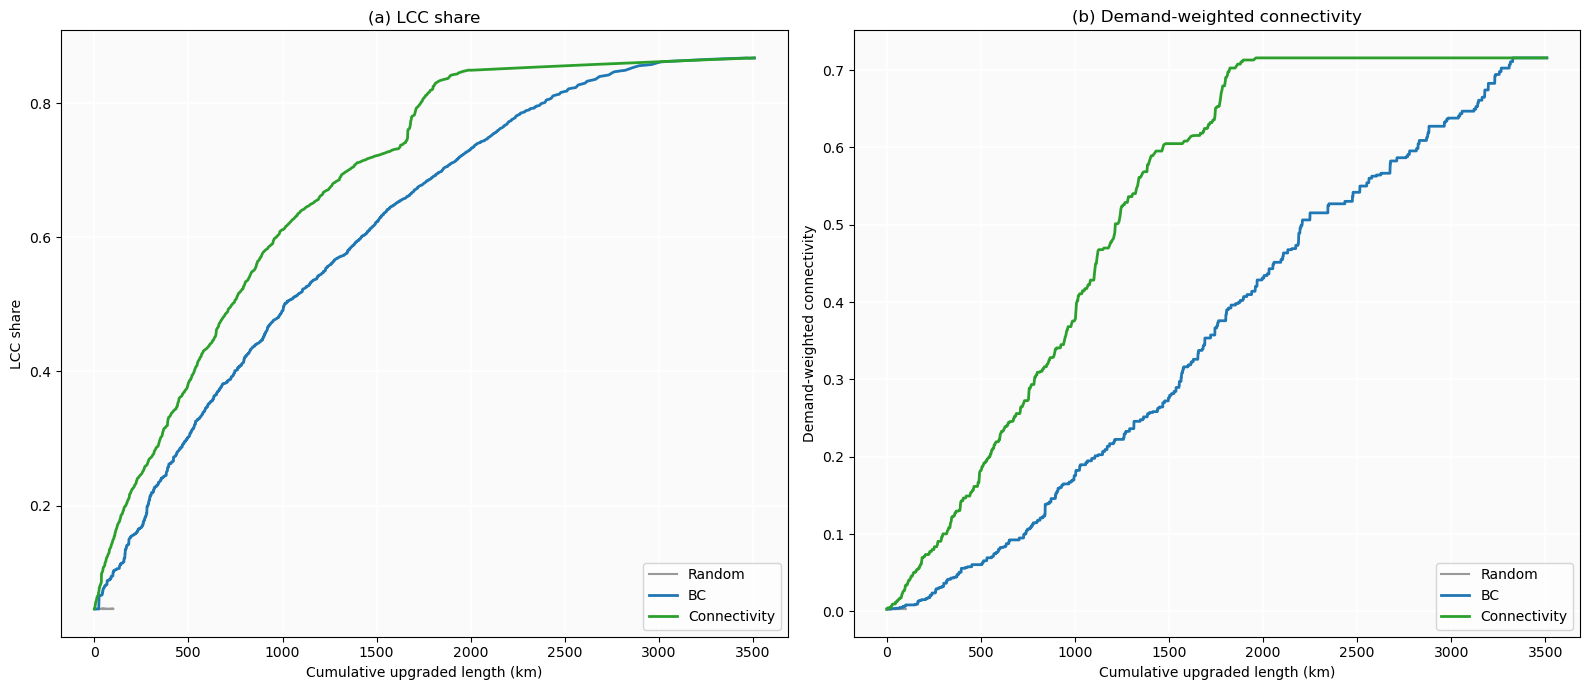

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

COLORS = {'BC': '#1f77b4', 'Connectivity': '#2ca02c', 'Random': '#999999'}

for ax, metric, ylabel in [
    (ax1, 'lcc_share', 'LCC share'),
    (ax2, 'dw_connectivity', 'Demand-weighted connectivity'),
]:
    ax.set_facecolor('#fafafa')
    ax.grid(True, color='white', linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)

    # Random: mean ± band
    rnd = results['Random']
    n_bins = 200
    bin_edges = np.linspace(0, rnd['cumul_upgrade_km'].max(), n_bins + 1)
    rnd['bin'] = pd.cut(rnd['cumul_upgrade_km'], bins=bin_edges, labels=False)
    rnd_agg = rnd.groupby('bin')[metric].agg(['mean', 'min', 'max'])
    rnd_x = (bin_edges[:-1] + bin_edges[1:]) / 2
    valid = rnd_agg['mean'].notna()
    ax.fill_between(rnd_x[valid], rnd_agg['min'].values[valid],
                    rnd_agg['max'].values[valid],
                    alpha=0.2, color=COLORS['Random'], zorder=2)
    ax.plot(rnd_x[valid], rnd_agg['mean'].values[valid],
            color=COLORS['Random'], label='Random', linewidth=1.5, zorder=3)

    for name in ['BC', 'Connectivity']:
        df = results[name]
        ax.plot(df['cumul_upgrade_km'], df[metric],
                color=COLORS[name], label=name, linewidth=2, zorder=4)

    ax.set_xlabel('Cumulative upgraded length (km)')
    ax.set_ylabel(ylabel)
    ax.legend(loc='lower right')

ax1.set_title('(a) LCC share')
ax2.set_title('(b) Demand-weighted connectivity')

plt.tight_layout()
plt.show()

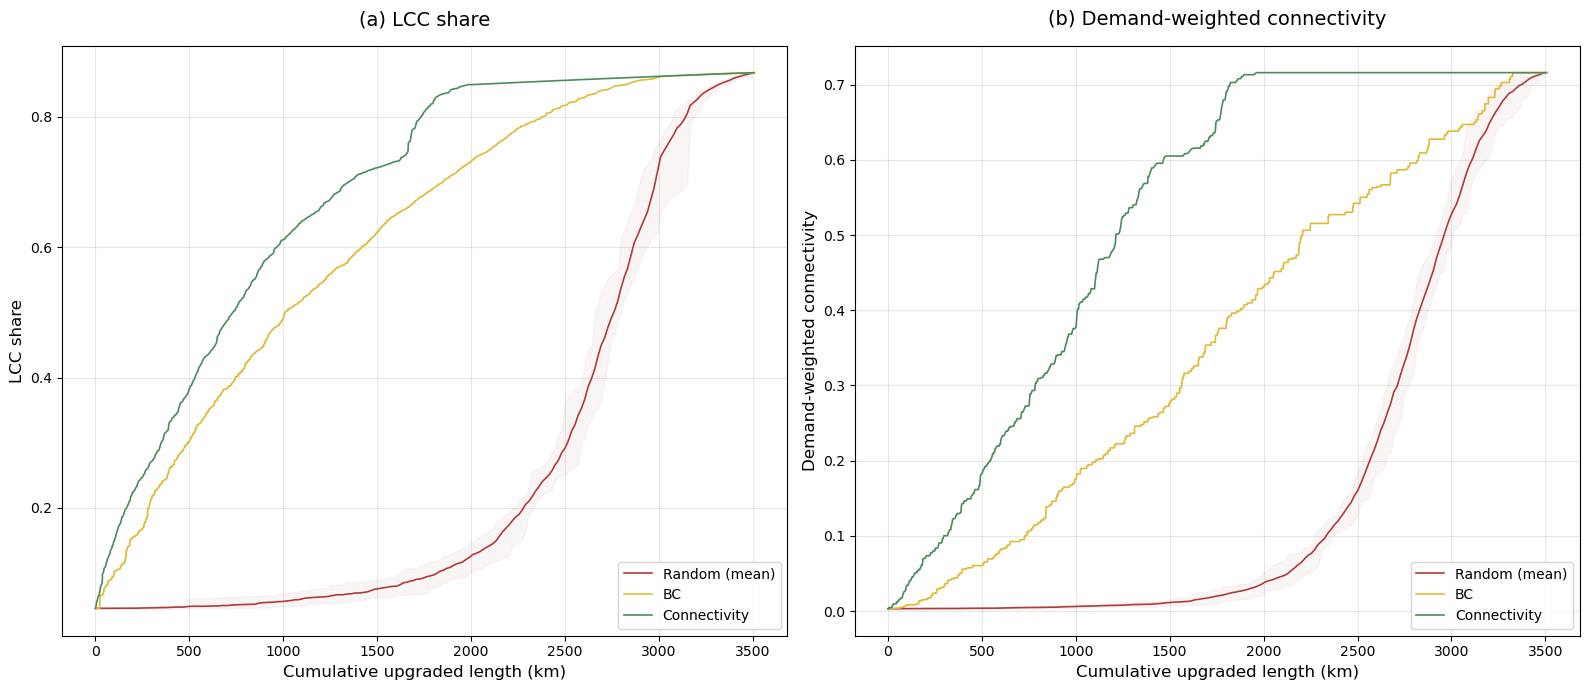

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

COLORS = {'BC': '#debc38', 'Connectivity': '#4a8c5c', 'Random': '#af3b3b'}

for ax, metric, ylabel in [
    (ax1, 'lcc_share', 'LCC share'),
    (ax2, 'dw_connectivity', 'Demand-weighted connectivity'),
]:
    ax.grid(True, alpha=0.3)

    # Random: mean + min/max band
    rnd = results['Random'].copy()
    n_bins = 200
    bin_edges = np.linspace(0, rnd['cumul_upgrade_km'].max(), n_bins + 1)
    rnd['bin'] = pd.cut(rnd['cumul_upgrade_km'], bins=bin_edges,
                        labels=False, include_lowest=True)
    rnd_agg = (rnd.groupby('bin')[metric]
                  .agg(['mean', 'min', 'max'])
                  .reindex(range(n_bins)))
    rnd_x = (bin_edges[:-1] + bin_edges[1:]) / 2
    valid = rnd_agg['mean'].notna()
    ax.fill_between(rnd_x[valid], rnd_agg['min'].values[valid],
                    rnd_agg['max'].values[valid],
                    alpha=0.05, color=COLORS['Random'], zorder=2)
    ax.plot(rnd_x[valid], rnd_agg['mean'].values[valid],
            color=COLORS['Random'], label='Random (mean)', linewidth=1.2, zorder=3)

    for name in ['BC', 'Connectivity']:
        df = results[name]
        ax.plot(df['cumul_upgrade_km'], df[metric],
                color=COLORS[name], label=name, linewidth=1.2, zorder=4)

    ax.set_xlabel('Cumulative upgraded length (km)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc='lower right', fontsize=10)

ax1.set_title('(a) LCC share', fontsize=14, pad=15)
ax2.set_title('(b) Demand-weighted connectivity', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

## 12b. First 100 km — fine-grained investment scenario

Re-runs each strategy over only the first 100 km of upgrades, recording both
metrics **after every single upgraded link** (`METRIC_INTERVAL_FINE = 1`) for a
near-continuous curve. This is the slow cell (10 random runs × every-link
metrics); increase the interval if runtime is a concern. Results go into a
separate `res100` dict, leaving the full-range `results` intact.

In [ ]:
# ── First 100 km, fine-grained: record metrics after EVERY upgraded link ──
# Stored in a separate res100 dict so the full-range `results` above are untouched.

METRIC_INTERVAL_FINE = 1   # update at every link
MAX_KM = 100


def run_fixed_order_capped(order, metric_interval, max_km):
    """Global fixed-order growth, capped at max_km, metrics every metric_interval edges."""
    uf, _ = init_uf_and_frontier(undir, node_to_cand, candidates)
    cumul_km = 0.0
    records = []
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = 0.0
    records.append(m)
    since = 0
    for idx in order:
        u, v = cand_u[idx], cand_v[idx]
        uf.add(u)
        uf.add(v)
        uf.union(u, v, cand_len[idx])
        cumul_km += cand_len_km[idx]
        since += 1
        if since >= metric_interval:
            m = compute_metrics(uf, od_node_pairs, total_flow)
            m['cumul_upgrade_km'] = cumul_km
            records.append(m)
            since = 0
        if cumul_km >= max_km:
            break
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = cumul_km
    records.append(m)
    return pd.DataFrame(records)


def run_connectivity_capped(metric_interval, max_km, seed=42):
    """Frontier-based Connectivity growth, capped at max_km, metrics every metric_interval edges."""
    uf, frontier = init_uf_and_frontier(undir, node_to_cand, candidates)
    remaining = set(candidates.index)
    rng = np.random.default_rng(seed)
    cumul_km = 0.0
    records = []
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = 0.0
    records.append(m)
    since = 0
    while frontier & remaining:
        active = frontier & remaining
        to_upgrade = select_connectivity(active, uf, rng)
        if not to_upgrade:
            break
        for idx in to_upgrade:
            u, v = cand_u[idx], cand_v[idx]
            uf.add(u)
            uf.add(v)
            uf.union(u, v, cand_len[idx])
            remaining.discard(idx)
            frontier.discard(idx)
            cumul_km += cand_len_km[idx]
            since += 1
            for node in (u, v):
                for ci in node_to_cand.get(node, set()):
                    if ci in remaining:
                        frontier.add(ci)
        if since >= metric_interval:
            m = compute_metrics(uf, od_node_pairs, total_flow)
            m['cumul_upgrade_km'] = cumul_km
            records.append(m)
            since = 0
        if cumul_km >= max_km:
            break
    m = compute_metrics(uf, od_node_pairs, total_flow)
    m['cumul_upgrade_km'] = cumul_km
    records.append(m)
    return pd.DataFrame(records)


res100 = {}

print(f"BC (first {MAX_KM} km, every link)...")
t0 = time.time()
bc_order = candidates.sort_values('bc', ascending=False).index.tolist()
res100['BC'] = run_fixed_order_capped(bc_order, METRIC_INTERVAL_FINE, MAX_KM)
print(f"  {len(res100['BC']):,} points in {time.time()-t0:.0f}s")

print(f"Connectivity (first {MAX_KM} km, every link)...")
t0 = time.time()
res100['Connectivity'] = run_connectivity_capped(METRIC_INTERVAL_FINE, MAX_KM)
print(f"  {len(res100['Connectivity']):,} points in {time.time()-t0:.0f}s")

print(f"Random (first {MAX_KM} km, every link, 10 runs)...")
t0 = time.time()
random_runs_100 = []
for run in range(10):
    rng = np.random.default_rng(run)
    order = list(candidates.index)
    rng.shuffle(order)
    df = run_fixed_order_capped(order, METRIC_INTERVAL_FINE, MAX_KM)
    df['run'] = run
    random_runs_100.append(df)
    print(f"  run {run+1}/10 done ({len(df):,} pts)")
res100['Random'] = pd.concat(random_runs_100, ignore_index=True)
print(f"  total {time.time()-t0:.0f}s")

print("Done. Full-range `results` left untouched.")

In [ ]:
# ── Plot: first 100 km, fine-grained (metrics after every link) ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

COLORS = {'Random': '#9a9a9a', 'BC': '#4c72b0', 'Connectivity': '#2f8f4e'}

for ax, metric, ylabel, panel in [
    (ax1, 'lcc_share', 'LCC share', '(a)'),
    (ax2, 'dw_connectivity', 'Demand-weighted connectivity', '(b)'),
]:
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

    # Random: mean + min/max envelope across the 10 runs (fine bins)
    rnd = res100['Random'].copy()
    n_bins = 200
    bin_edges = np.linspace(0, MAX_KM, n_bins + 1)
    rnd['bin'] = pd.cut(rnd['cumul_upgrade_km'], bins=bin_edges,
                        labels=False, include_lowest=True)
    agg = (rnd.groupby('bin')[metric]
              .agg(['mean', 'min', 'max'])
              .reindex(range(n_bins)))
    x = (bin_edges[:-1] + bin_edges[1:]) / 2
    valid = agg['mean'].notna()
    ax.fill_between(x[valid], agg['min'].values[valid], agg['max'].values[valid],
                    color=COLORS['Random'], alpha=0.18, linewidth=0, zorder=2)
    ax.plot(x[valid], agg['mean'].values[valid], color=COLORS['Random'],
            lw=1.4, zorder=3, label='Random (mean of 10)')

    # BC and Connectivity: near-continuous per-link curves
    for name in ['BC', 'Connectivity']:
        df = res100[name]
        ax.plot(df['cumul_upgrade_km'], df[metric], color=COLORS[name],
                lw=1.8, zorder=4, label=name, solid_capstyle='round')

    ax.set_xlim(0, MAX_KM)
    ax.set_xlabel('Cumulative upgraded length (km)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{panel} {ylabel} (first {MAX_KM} km)', fontsize=12, pad=10)
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'growth_curves_100km.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Summary

In [60]:
print("=" * 70)
print("FINAL STATE COMPARISON")
print("=" * 70)
print(f"{'Strategy':<20} {'Upgrade km':>12} {'LCC share':>12} {'DW conn':>12} {'Components':>12}")
print("-" * 70)

for name in ['BC', 'Connectivity']:
    final = results[name].iloc[-1]
    print(f"{name:<20} {final['cumul_upgrade_km']:>12.1f} "
          f"{final['lcc_share']:>12.4f} {final['dw_connectivity']:>12.4f} "
          f"{final['n_components']:>12.0f}")

rnd_final = results['Random'].groupby('run').last()
print(f"{'Random (mean)':<20} {rnd_final['cumul_upgrade_km'].mean():>12.1f} "
      f"{rnd_final['lcc_share'].mean():>12.4f} {rnd_final['dw_connectivity'].mean():>12.4f} "
      f"{rnd_final['n_components'].mean():>12.0f}")

FINAL STATE COMPARISON
Strategy               Upgrade km    LCC share      DW conn   Components
----------------------------------------------------------------------
BC                         3508.8       0.8677       0.7159        21944
Connectivity               3506.1       0.8679       0.7159        21938
Random (mean)               100.0       0.0458       0.0032        32222


## 14. Export

In [ ]:
for name, df in results.items():
    out = OUTPUT_DIR / f"growth_{name.lower()}.csv"
    df.to_csv(out, index=False)
    print(f"Saved: {out}")

for name, df in res100.items():
    out = OUTPUT_DIR / f"growth_{name.lower()}_100km.csv"
    df.to_csv(out, index=False)
    print(f"Saved: {out}")

print("\nDone.")